<a href="https://colab.research.google.com/github/jayden14141/Network-Anomaly-Detection/blob/main/ml/notebooks/02_data_leakage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import gc
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# Load data
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    data = pd.read_csv('/content/drive/MyDrive/cicids2017_selected.csv')
    print(f"Loaded from Drive: {data.shape}")
except:
    from google.colab import files
    uploaded = files.upload()
    data = pd.read_csv('cicids2017_selected.csv')
    print(f"Loaded from upload: {data.shape}")

Mounted at /content/drive
Loaded from Drive: (2827876, 48)


In [2]:
# Preprocessing
data.columns = data.columns.str.strip()
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)
data['is_attack'] = (data['Label'] != 'BENIGN').astype(int)
feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols.remove('is_attack')
print(f"Preprocessed: {data.shape}, Features: {len(feature_cols)}")

Preprocessed: (2827876, 48), Features: 46


In [3]:
# Experiment 1: Time-based split (80/20, no shuffle)
# CICIDS data is ordered by capture time
split_idx = int(len(data) * 0.8)

X_train_1 = data.iloc[:split_idx][feature_cols]
X_test_1 = data.iloc[split_idx:][feature_cols]
y_train_1 = data.iloc[:split_idx]['is_attack']
y_test_1 = data.iloc[split_idx:]['is_attack']

scaler_1 = StandardScaler()
X_train_1_scaled = scaler_1.fit_transform(X_train_1)
X_test_1_scaled = scaler_1.transform(X_test_1)

del X_train_1, X_test_1
gc.collect()

xgb_1 = XGBClassifier(n_estimators=100, max_depth=6, random_state=42, eval_metric='logloss')
xgb_1.fit(X_train_1_scaled, y_train_1)
y_pred_1 = xgb_1.predict(X_test_1_scaled)

print("Experiment 1: Time-based split (80/20)")
print(classification_report(y_test_1, y_pred_1, target_names=['Benign', 'Attack']))

# Store results
exp1_f1 = f1_score(y_test_1, y_pred_1)
exp1_precision = precision_score(y_test_1, y_pred_1)
exp1_recall = recall_score(y_test_1, y_pred_1)

del X_train_1_scaled, X_test_1_scaled, xgb_1, y_pred_1
gc.collect()
print("Memory freed.")

Experiment 1: Time-based split (80/20)
              precision    recall  f1-score   support

      Benign       0.99      1.00      0.99    373624
      Attack       1.00      0.98      0.99    191952

    accuracy                           0.99    565576
   macro avg       0.99      0.99      0.99    565576
weighted avg       0.99      0.99      0.99    565576

Memory freed.


In [9]:
# Experiment 2: Strict time-based split with 30% buffer
# Train on first 50%, skip middle 30%, test on last 20%
train_end = int(len(data) * 0.75)
test_start = int(len(data) * 0.8)

X_train_2 = data.iloc[:train_end][feature_cols]
X_test_2 = data.iloc[test_start:][feature_cols]
y_train_2 = data.iloc[:train_end]['is_attack']
y_test_2 = data.iloc[test_start:]['is_attack']

scaler_2 = StandardScaler()
X_train_2_scaled = scaler_2.fit_transform(X_train_2)
X_test_2_scaled = scaler_2.transform(X_test_2)

# del X_train_2, X_test_2, data
# gc.collect()

xgb_2 = XGBClassifier(n_estimators=100, max_depth=6, random_state=42, eval_metric='logloss')
xgb_2.fit(X_train_2_scaled, y_train_2)
y_pred_2 = xgb_2.predict(X_test_2_scaled)

print("Experiment 2: Strict time-based split (75% train / 5% buffer / 20% test)")
print(classification_report(y_test_2, y_pred_2, target_names=['Benign', 'Attack']))

# Store results
exp2_f1 = f1_score(y_test_2, y_pred_2)
exp2_precision = precision_score(y_test_2, y_pred_2)
exp2_recall = recall_score(y_test_2, y_pred_2)

Experiment 2: Strict time-based split (75% train / 5% buffer / 20% test)
              precision    recall  f1-score   support

      Benign       0.71      1.00      0.83    373624
      Attack       1.00      0.22      0.37    191952

    accuracy                           0.74    565576
   macro avg       0.86      0.61      0.60    565576
weighted avg       0.81      0.74      0.68    565576



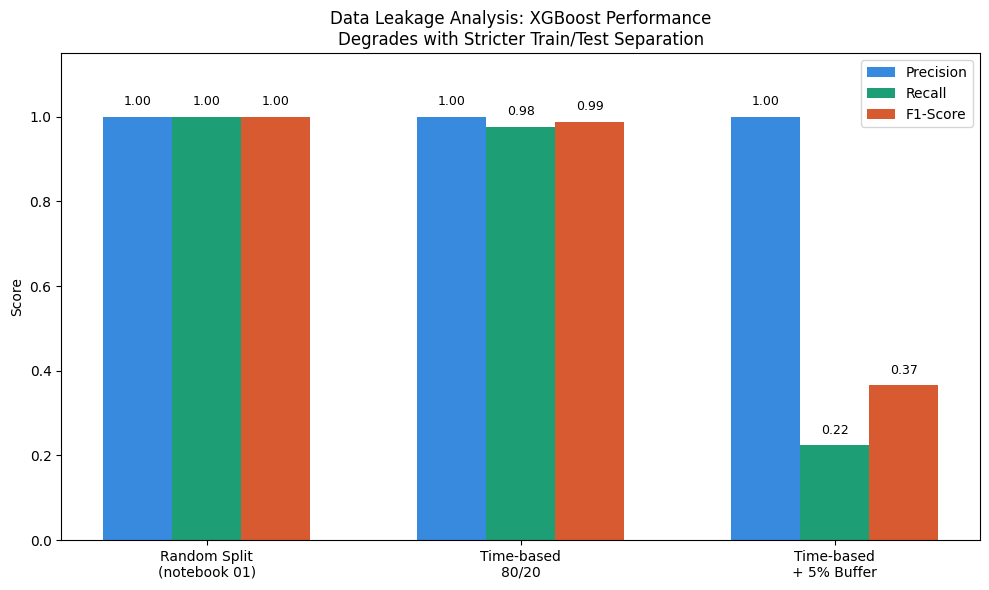


Random split Attack F1:         1.00
Time-based 80/20 Attack F1:     0.9877
Time-based + buffer Attack F1:  0.3662

Drop from random to strict:     0.6338


In [10]:
# Comparison visualization: all 3 splits
splits = ['Random Split\n(notebook 01)', 'Time-based\n80/20', 'Time-based\n+ 5% Buffer']
f1_scores = [1.00, exp1_f1, exp2_f1]
precisions = [1.00, exp1_precision, exp2_precision]
recalls = [1.00, exp1_recall, exp2_recall]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(splits))
width = 0.22

bars1 = ax.bar(x - width, precisions, width, label='Precision', color='#378ADD')
bars2 = ax.bar(x, recalls, width, label='Recall', color='#1D9E75')
bars3 = ax.bar(x + width, f1_scores, width, label='F1-Score', color='#D85A30')

ax.set_ylabel('Score')
ax.set_title('Data Leakage Analysis: XGBoost Performance\nDegrades with Stricter Train/Test Separation')
ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.legend()
ax.set_ylim(0, 1.15)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nRandom split Attack F1:         1.00")
print(f"Time-based 80/20 Attack F1:     {exp1_f1:.4f}")
print(f"Time-based + buffer Attack F1:  {exp2_f1:.4f}")
print(f"\nDrop from random to strict:     {1.00 - exp2_f1:.4f}")